# 생활계폐기물 발생량 및 처리현황 EDA

이 노트북은 서울시 자치구별 생활계폐기물 데이터에서 `일일 소각 필요량`을 계산하기 위한 탐색 과정을 담습니다.


In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120


DATA_DIR = Path('../../data/raw/소각장')
OUTPUT_DIR = Path('../../outputs/소각장')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

xlsx_path = next(path for path in DATA_DIR.glob('*.xlsx') if '생활계폐기물' in path.name)

# 현재 파일은 다중 헤더 구조일 가능성이 높으므로 우선 header=None으로 원본 형태를 확인합니다.
raw_df = pd.read_excel(xlsx_path, sheet_name='데이터', header=None)
print(f'파일명: {xlsx_path.name}')

파일명: 생활계폐기물+발생량+및+처리현황(2020년+이후)_20260320213930.xlsx


c:\Users\windows\AppData\Local\Programs\Python\Python313\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


## 1. 데이터 첫 확인

다중 헤더 엑셀은 바로 컬럼명을 신뢰하면 안 됩니다.
먼저 원본 시트 전체를 확인한 뒤 실제 데이터 시작 행과 헤더 구조를 파악합니다.

In [14]:
print('raw shape:', raw_df.shape)
print('\nraw columns:')
print(raw_df.columns.tolist())
display(raw_df.head(10))

raw shape: (30, 9)

raw columns:
[0, 1, 2, 3, 4, 5, 6, 7, 8]


,0,1,2,3,4,5,6,7,8
0,구분별(1),구분별(2),2024,2024,2024,2024,2024,2024,2024
1,구분별(1),구분별(2),발생량,재활용,재활용,재활용,소각,매립,기타
2,구분별(1),구분별(2),소계,소계,재활용,음식물,소계,소계,소계
3,계,소계,3836977,2373762,1507567,866195,908918,214165,340132
4,NaN,처리비율,100,61.9,39.3,22.6,23.7,5.6,8.9
5,NaN,종로구,98887,58688,29130,29559,35903,3869,427
6,NaN,중구,133576,85767,47751,38016,41851,4641,1318
7,NaN,용산구,103895,67515,42197,25318,32618,3506,257
8,NaN,성동구,159245,120565,93089,27476,30444,6175,2062
9,NaN,광진구,107234,71082,41987,29096,27968,8176,8


## 2. 실제 분석용 테이블 만들기

현재 파일은 상단에 다중 헤더가 있으므로, 자치구 데이터가 시작하는 행부터 잘라서 분석용 컬럼명을 다시 지정

In [15]:
# 헤더 행(0~2)과 합계/비율 행(3~4)을 건너뛰고 자치구 데이터만 추출합니다.
# 헤더 구조: Row0=연도, Row1=대분류, Row2=소분류
# 실제 컬럼: 구분별1 | 자치구명 | 발생량(소계) | 재활용(소계) | 재활용(재활용) | 재활용(음식물) | 소각(소계) | 매립(소계) | 기타(소계)

# 연도를 헤더에서 추출합니다.
data_year = int(raw_df.iloc[0, 2])
print(f'데이터 연도: {data_year}')

df = raw_df.iloc[5:].copy()
df = df.iloc[:, :9]
df.columns = ['구분별1', '자치구명', '발생량', '재활용소계', '재활용', '음식물', '소각량', '매립량', '기타']

# 자치구 행만 남깁니다.
df = df[df['자치구명'].astype(str).str.endswith('구')].copy()

# 수치형 컬럼은 분석을 위해 숫자로 변환합니다.
numeric_cols = ['발생량', '재활용소계', '재활용', '음식물', '소각량', '매립량', '기타']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'자치구 수: {df.shape[0]}개')
display(df.head())

데이터 연도: 2024
자치구 수: 25개


,구분별1,자치구명,발생량,재활용소계,재활용,음식물,소각량,매립량,기타
5,NaN,종로구,98887,58688,29130,29559,35903,3869,427.0
6,NaN,중구,133576,85767,47751,38016,41851,4641,1318.0
7,NaN,용산구,103895,67515,42197,25318,32618,3506,257.0
8,NaN,성동구,159245,120565,93089,27476,30444,6175,2062.0
9,NaN,광진구,107234,71082,41987,29096,27968,8176,8.0


## 3. 컬럼 구성, 연도 범위, 자치구 수 확인


In [16]:
print('columns:', df.columns.tolist())
print('자치구 수:', df['자치구명'].nunique())

# 연도는 엑셀 헤더(Row 0)에서 추출한 값을 사용합니다.
df['연도'] = data_year
print('연도:', data_year)

print('\n결측값 개수:')
print(df[numeric_cols].isna().sum())

columns: ['구분별1', '자치구명', '발생량', '재활용소계', '재활용', '음식물', '소각량', '매립량', '기타']
자치구 수: 25
연도: 2024

결측값 개수:
발생량      0
재활용소계    0
재활용      0
음식물      0
소각량      0
매립량      0
기타       3
dtype: int64


## 4. 발생량 합계 검증

데이터 품질을 확인하기 위해 `발생량 = 재활용소계 + 소각량 + 매립량 + 기타`가 맞는지 검증

In [17]:
df['합계검증값'] = df['재활용소계'].fillna(0) + df['소각량'].fillna(0) + df['매립량'].fillna(0) + df['기타'].fillna(0)
df['오차'] = df['발생량'] - df['합계검증값']

display(df[['자치구명', '발생량', '합계검증값', '오차']].head())
print('최대 절대오차:', df['오차'].abs().max())

,자치구명,발생량,합계검증값,오차
5,종로구,98887,98887.0,0.0
6,중구,133576,133577.0,-1.0
7,용산구,103895,103896.0,-1.0
8,성동구,159245,159246.0,-1.0
9,광진구,107234,107234.0,0.0


최대 절대오차: 1.0


### Insight: 합계 검증 결과

- 최대 절대 오차가 1톤 이내이므로 반올림 차이 수준입니다. 헤더 파싱 및 컬럼 매핑이 정확함을 확인했습니다.
- `기타` 컬럼에 3개 자치구(강북구, 은평구, 관악구)의 결측값이 있으며, 이는 해당 구에 중간처분량이 없는 것으로 해석됩니다.

## 5. 자치구별 소각량과 일일 소각 필요량 계산

 `일일 소각 필요량` =  `소각량 ÷ 365`로 계산.

In [18]:
df['일일소각필요량_톤'] = df['소각량'] / 365

rank_df = df.sort_values('소각량', ascending=False)[['자치구명', '소각량', '일일소각필요량_톤']]
display(rank_df)

,자치구명,소각량,일일소각필요량_톤
27,강남구,85233,233.515068
20,강서구,50371,138.002740
18,마포구,49895,136.698630
28,송파구,48885,133.931507
26,서초구,47403,129.871233
21,구로구,44102,120.827397
23,영등포구,42491,116.413699
6,중구,41851,114.660274
15,노원구,41725,114.315068
11,중랑구,37416,102.509589


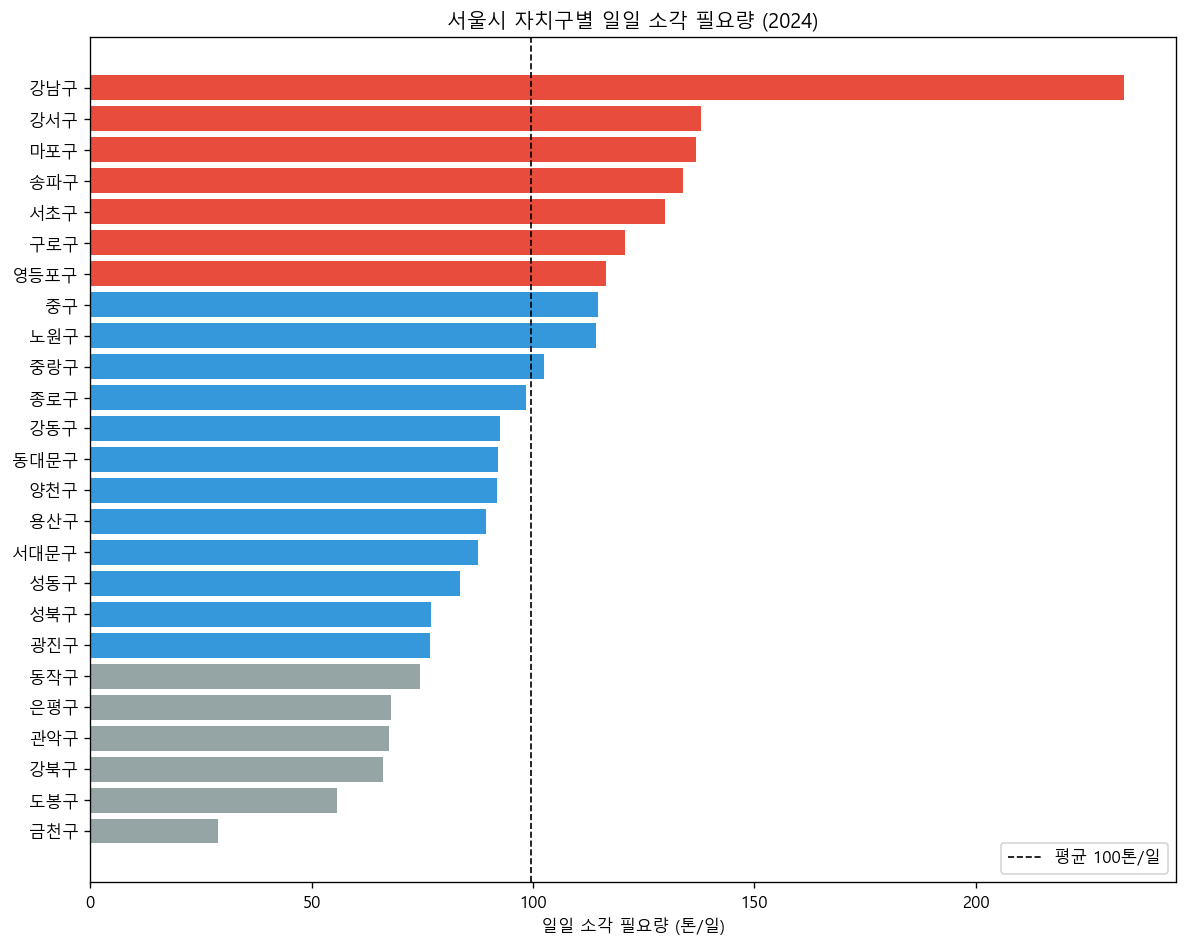

In [19]:
# 자치구별 일일 소각 필요량 수평 막대 그래프
plot_df = df.sort_values('일일소각필요량_톤')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v >= df['일일소각필요량_톤'].quantile(0.75) else
          '#3498db' if v >= df['일일소각필요량_톤'].quantile(0.25) else
          '#95a5a6' for v in plot_df['일일소각필요량_톤']]
ax.barh(plot_df['자치구명'], plot_df['일일소각필요량_톤'], color=colors)
ax.axvline(df['일일소각필요량_톤'].mean(), color='black', linestyle='--', linewidth=1, label=f'평균 {df["일일소각필요량_톤"].mean():.0f}톤/일')
ax.set_xlabel('일일 소각 필요량 (톤/일)')
ax.set_title('서울시 자치구별 일일 소각 필요량 (2024)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '자치구별_일일소각필요량.png', bbox_inches='tight')
plt.show()

### Insight: 일일 소각 필요량 분포

- **25개 자치구** 전체 일일 소각 필요량 합계: 약 **2,490톤/일**
- **최대**: 강남구 (약 234톤/일) -- 2위(강서구 138톤/일) 대비 약 1.7배
- **최소**: 금천구 (약 29톤/일) -- 강남구의 약 1/8 수준
- **평균**: 약 100톤/일, **표준편차**: 약 39톤/일
- 상위 5개구(강남, 강서, 마포, 송파, 서초)가 전체 소각량의 약 32%를 차지합니다.

## 6. 기타(중간처분) 규모 확인

`기타`는 소각과 별개인 중간처분 성격일 수 있으므로, 소각량 대비 비율을 함께 봄.

In [20]:
df['기타_소각비율'] = df['기타'] / df['소각량']
display(df[['자치구명', '기타', '소각량', '기타_소각비율']].sort_values('기타_소각비율', ascending=False))

,자치구명,기타,소각량,기타_소각비율
20,강서구,255967.0,50371,5.081634
28,송파구,42814.0,48885,0.875811
19,양천구,9522.0,33545,0.283858
15,노원구,10329.0,41725,0.247549
14,도봉구,4276.0,20306,0.210578
24,동작구,2544.0,27158,0.093674
26,서초구,3385.0,47403,0.071409
8,성동구,2062.0,30444,0.067731
22,금천구,570.0,10564,0.053957
6,중구,1318.0,41851,0.031493


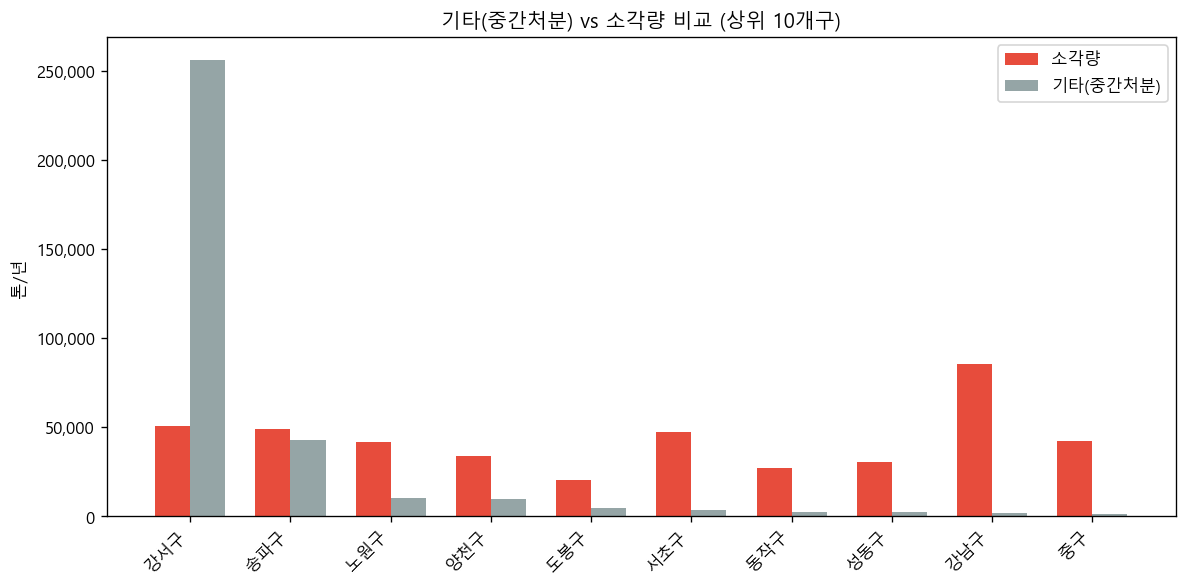

In [21]:
# 기타(중간처분) vs 소각량 비교 (상위 10개구)
etc_df = df[['자치구명', '기타', '소각량']].dropna().sort_values('기타', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(etc_df))
w = 0.35
ax.bar([i - w/2 for i in x], etc_df['소각량'], w, label='소각량', color='#e74c3c')
ax.bar([i + w/2 for i in x], etc_df['기타'], w, label='기타(중간처분)', color='#95a5a6')
ax.set_xticks(list(x))
ax.set_xticklabels(etc_df['자치구명'], rotation=45, ha='right')
ax.set_ylabel('톤/년')
ax.set_title('기타(중간처분) vs 소각량 비교 (상위 10개구)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, p: f'{v:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '기타_소각_비교.png', bbox_inches='tight')
plt.show()

### Insight: 기타(중간처분) 이상값

- **강서구**의 기타(중간처분)량이 **255,967톤**으로 소각량(50,371톤)의 약 5배에 달함.
  - 이는 강서구 발생량(590,910톤) 중 43%가 '기타'로 분류되는 것이며, 다른 구 대비 극단적으로 높음.
  - 마곡지대 사업폐기물 때문?
- 강북구, 은평구, 관악구는 기타가 결측치

## 7. 처리 방식별 비율 분석

각 자치구의 폐기물 처리 비율(재활용, 소각, 매립, 기타)을 계산하여 구별 처리 패턴 차이를 파악

In [22]:
# 처리 방식별 비율 계산
df['재활용비율'] = (df['재활용소계'] / df['발생량'] * 100).round(1)
df['소각비율'] = (df['소각량'] / df['발생량'] * 100).round(1)
df['매립비율'] = (df['매립량'] / df['발생량'] * 100).round(1)
df['기타비율'] = (df['기타'].fillna(0) / df['발생량'] * 100).round(1)

ratio_cols = ['자치구명', '발생량', '재활용비율', '소각비율', '매립비율', '기타비율']
ratio_df = df[ratio_cols].sort_values('소각비율', ascending=False)

print('=== 자치구별 처리 비율 (%) ===')
display(ratio_df)

print(f'\n소각비율 최고: {ratio_df.iloc[0]["자치구명"]} ({ratio_df.iloc[0]["소각비율"]}%)')
print(f'소각비율 최저: {ratio_df.iloc[-1]["자치구명"]} ({ratio_df.iloc[-1]["소각비율"]}%)')
print(f'평균 소각비율: {df["소각비율"].mean():.1f}%')

=== 자치구별 처리 비율 (%) ===


,자치구명,발생량,재활용비율,소각비율,매립비율,기타비율
5,종로구,98887,59.3,36.3,3.9,0.4
21,구로구,122831,58.1,35.9,5.7,0.3
18,마포구,142121,60.1,35.1,3.9,0.9
11,중랑구,107223,62.3,34.9,2.7,0.0
17,서대문구,99837,63.6,32.0,4.3,0.1
27,강남구,266815,63.4,31.9,4.0,0.7
7,용산구,103895,65.0,31.4,3.4,0.2
6,중구,133576,64.2,31.3,3.5,1.0
10,동대문구,112593,65.2,29.9,4.1,0.8
13,강북구,83607,68.5,28.8,2.7,0.0



소각비율 최고: 종로구 (36.3%)
소각비율 최저: 강서구 (8.5%)
평균 소각비율: 26.0%


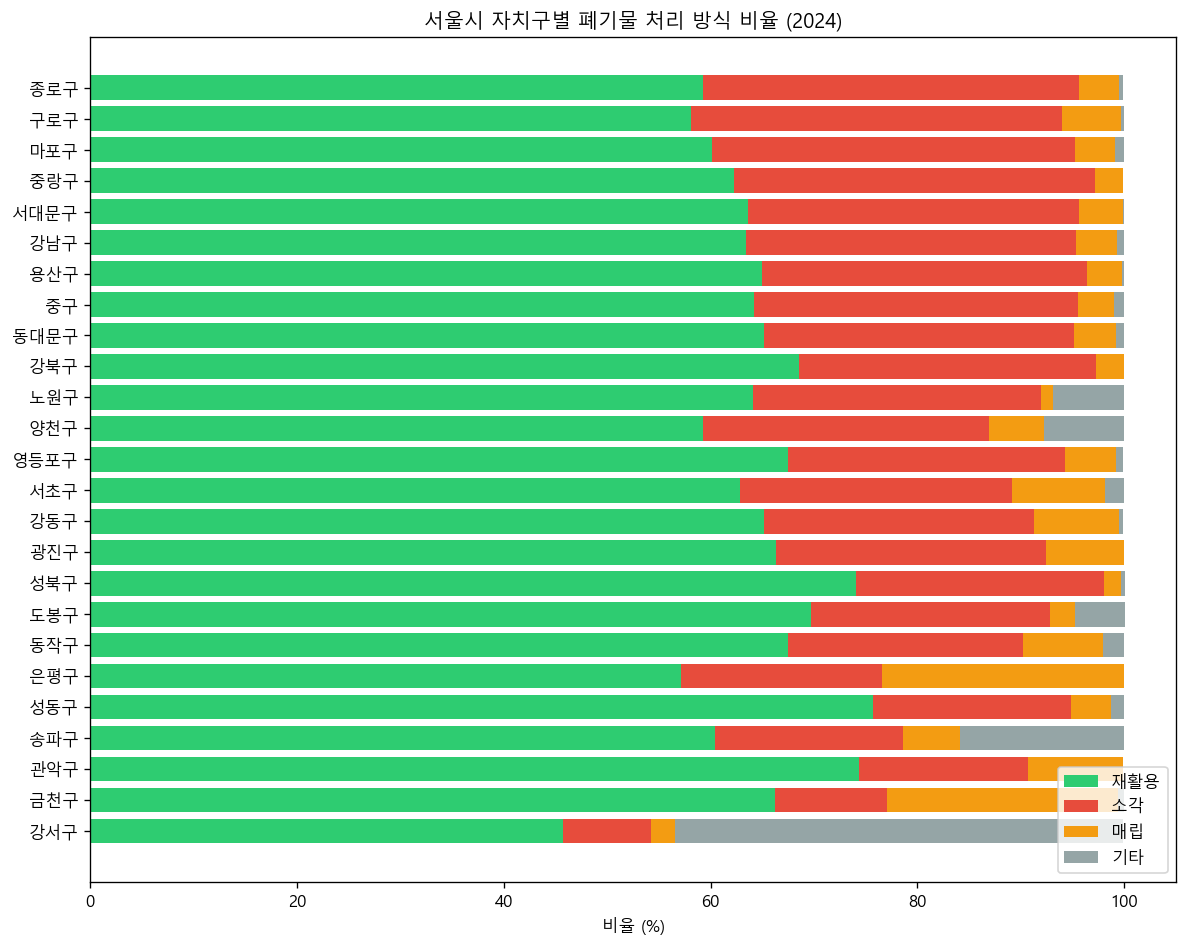

In [23]:
# 자치구별 처리 방식 비율 누적 막대 그래프
stack_df = df.sort_values('소각비율', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(stack_df['자치구명'], stack_df['재활용비율'], label='재활용', color='#2ecc71')
ax.barh(stack_df['자치구명'], stack_df['소각비율'], left=stack_df['재활용비율'], label='소각', color='#e74c3c')
ax.barh(stack_df['자치구명'], stack_df['매립비율'], left=stack_df['재활용비율']+stack_df['소각비율'], label='매립', color='#f39c12')
ax.barh(stack_df['자치구명'], stack_df['기타비율'], left=stack_df['재활용비율']+stack_df['소각비율']+stack_df['매립비율'], label='기타', color='#95a5a6')
ax.set_xlabel('비율 (%)')
ax.set_title('서울시 자치구별 폐기물 처리 방식 비율 (2024)')
ax.legend(loc='lower right')
ax.set_xlim(0, 105)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '처리방식_비율_누적.png', bbox_inches='tight')
plt.show()

## 8. 일일 소각 필요량 분포 통계

소각 수요의 분포 형태와 주요 통계량

In [24]:
# 일일 소각 필요량 분포 통계
print('=== 일일 소각 필요량 분포 (톤/일) ===')
print(df['일일소각필요량_톤'].describe().round(1))

# 사분위별 자치구 분류
q1 = df['일일소각필요량_톤'].quantile(0.25)
q3 = df['일일소각필요량_톤'].quantile(0.75)
median = df['일일소각필요량_톤'].median()

print(f'\nQ1 (25%): {q1:.1f}톤/일')
print(f'중앙값:   {median:.1f}톤/일')
print(f'Q3 (75%): {q3:.1f}톤/일')

print(f'\n--- 상위 그룹 (Q3 이상, {q3:.0f}톤/일 초과) ---')
high = df[df['일일소각필요량_톤'] >= q3].sort_values('일일소각필요량_톤', ascending=False)
print(high[['자치구명', '일일소각필요량_톤']].to_string(index=False))

print(f'\n--- 하위 그룹 (Q1 이하, {q1:.0f}톤/일 미만) ---')
low = df[df['일일소각필요량_톤'] <= q1].sort_values('일일소각필요량_톤')
print(low[['자치구명', '일일소각필요량_톤']].to_string(index=False))

=== 일일 소각 필요량 분포 (톤/일) ===
count     25.0
mean      99.6
std       39.0
min       28.9
25%       76.6
50%       92.1
75%      116.4
max      233.5
Name: 일일소각필요량_톤, dtype: float64

Q1 (25%): 76.6톤/일
중앙값:   92.1톤/일
Q3 (75%): 116.4톤/일

--- 상위 그룹 (Q3 이상, 116톤/일 초과) ---
자치구명  일일소각필요량_톤
 강남구 233.515068
 강서구 138.002740
 마포구 136.698630
 송파구 133.931507
 서초구 129.871233
 구로구 120.827397
영등포구 116.413699

--- 하위 그룹 (Q1 이하, 77톤/일 미만) ---
자치구명  일일소각필요량_톤
 금천구  28.942466
 도봉구  55.632877
 강북구  66.030137
 관악구  67.534247
 은평구  67.953425
 동작구  74.405479
 광진구  76.624658


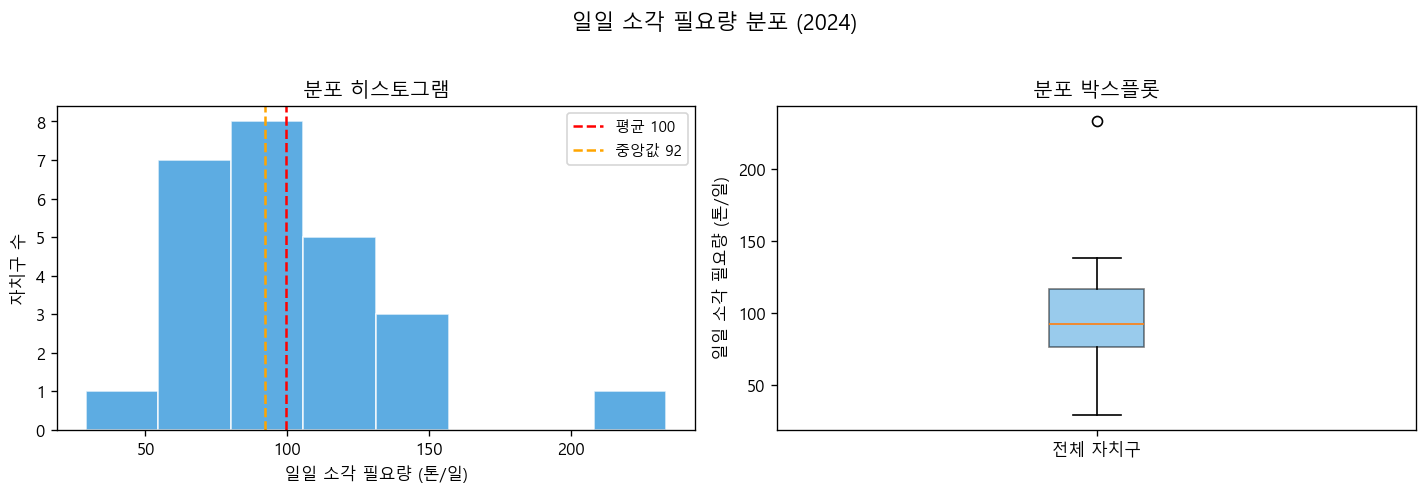

In [25]:
# 일일 소각 필요량 히스토그램 + 박스플롯
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 히스토그램
ax1.hist(df['일일소각필요량_톤'], bins=8, color='#3498db', edgecolor='white', alpha=0.8)
ax1.axvline(df['일일소각필요량_톤'].mean(), color='red', linestyle='--', label=f'평균 {df["일일소각필요량_톤"].mean():.0f}')
ax1.axvline(df['일일소각필요량_톤'].median(), color='orange', linestyle='--', label=f'중앙값 {df["일일소각필요량_톤"].median():.0f}')
ax1.set_xlabel('일일 소각 필요량 (톤/일)')
ax1.set_ylabel('자치구 수')
ax1.set_title('분포 히스토그램')
ax1.legend(fontsize=9)

# 박스플롯
bp = ax2.boxplot(df['일일소각필요량_톤'], vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#3498db', alpha=0.5))
ax2.set_ylabel('일일 소각 필요량 (톤/일)')
ax2.set_title('분포 박스플롯')
ax2.set_xticklabels(['전체 자치구'])

plt.suptitle('일일 소각 필요량 분포 (2024)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '소각필요량_분포.png', bbox_inches='tight')
plt.show()

## 9. 소각 수요 순위 데이터 저장

대시보드에서 활용할 수 있도록 일일 소각 필요량 순위 데이터를 별도 CSV로 저장

In [26]:
# 대시보드용 핵심 데이터 저장
export_cols = ['자치구명', '연도', '발생량', '재활용소계', '소각량', '매립량', '기타',
               '일일소각필요량_톤', '재활용비율', '소각비율', '매립비율']
export_df = df[export_cols].sort_values('일일소각필요량_톤', ascending=False).reset_index(drop=True)
export_df.index = export_df.index + 1  # 1-based ranking
export_df.index.name = '순위'

display(export_df)

export_df.to_csv(OUTPUT_DIR / 'seoul_daily_incineration_demand.csv', encoding='utf-8-sig')
print(f'\n저장 완료: {OUTPUT_DIR / "seoul_daily_incineration_demand.csv"}')

,자치구명,연도,발생량,재활용소계,소각량,매립량,기타,일일소각필요량_톤,재활용비율,소각비율,매립비율
순위,,,,,,,,,,,
1,강남구,2024,266815,169222,85233,10546,1814.0,233.515068,63.4,31.9,4.0
2,강서구,2024,590910,270188,50371,14385,255967.0,138.002740,45.7,8.5,2.4
3,마포구,2024,142121,85360,49895,5601,1266.0,136.698630,60.1,35.1,3.9
4,송파구,2024,268890,162401,48885,14789,42814.0,133.931507,60.4,18.2,5.5
5,서초구,2024,180257,113288,47403,16181,3385.0,129.871233,62.8,26.3,9.0
6,구로구,2024,122831,71343,44102,7011,375.0,120.827397,58.1,35.9,5.7
7,영등포구,2024,158377,106906,42491,7829,1150.0,116.413699,67.5,26.8,4.9
8,중구,2024,133576,85767,41851,4641,1318.0,114.660274,64.2,31.3,3.5
9,노원구,2024,150001,96090,41725,1856,10329.0,114.315068,64.1,27.8,1.2



저장 완료: ..\..\outputs\eda\seoul_daily_incineration_demand.csv
